## Préparation des données

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du livrable
df = pd.read_csv("../data/donnees.csv")
#df = pd.read_csv("../data/test7.csv")

# Nettoyage : conversion numérique
df['CVSS'] = pd.to_numeric(df['CVSS'], errors='coerce')
df['EPSS'] = pd.to_numeric(df['EPSS'], errors='coerce')

## Les graphiques

### Nuage de points (Scatter Plot) : CVSS vs EPSS

Si une CVE est en haut à droite (CVSS 9.8 + EPSS 0.95), c'est une urgence absolue

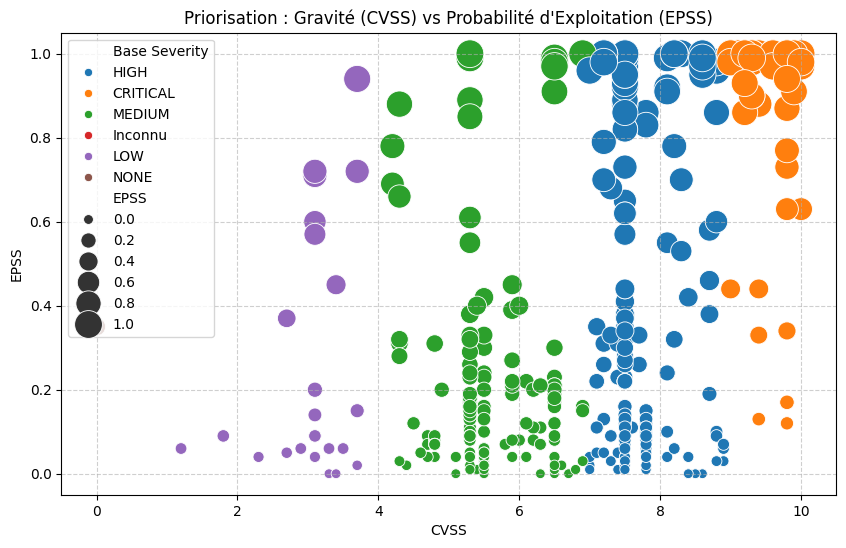

In [102]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CVSS', y='EPSS', hue='Base Severity', size='EPSS', sizes=(50, 400))
plt.title("Priorisation : Gravité (CVSS) vs Probabilité d'Exploitation (EPSS)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Distribution des scores CVSS (Histogramme)

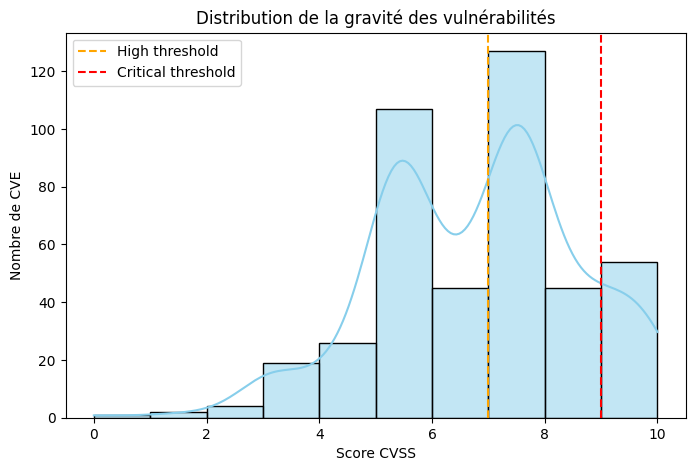

In [103]:
plt.figure(figsize=(8, 5))
sns.histplot(df['CVSS'], bins=10, kde=True, color='skyblue')
plt.axvline(x=7.0, color='orange', linestyle='--', label='High threshold')
plt.axvline(x=9.0, color='red', linestyle='--', label='Critical threshold')
plt.title("Distribution de la gravité des vulnérabilités")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.legend()
plt.show()

### Top 5 des faiblesses les plus fréquentes (CWE)

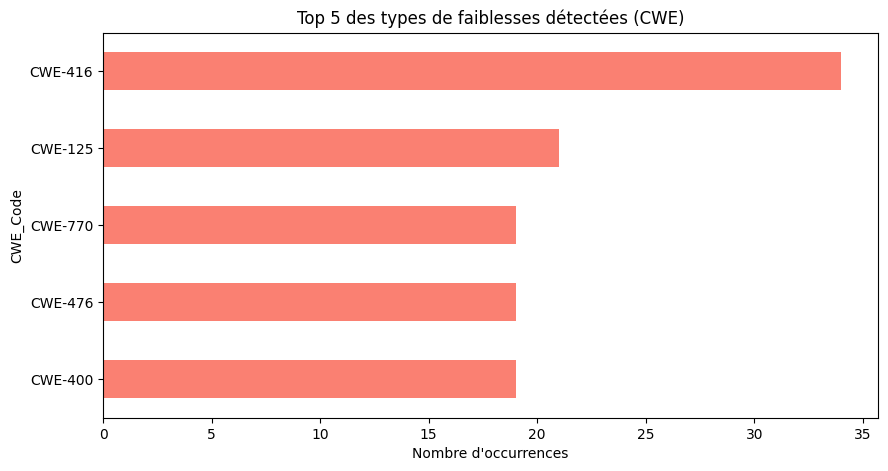

In [104]:
# On extrait juste le code CWE (ex: CWE-123) pour plus de clarté
df['CWE_Code'] = df['CWE'].str.extract(r'(CWE-\d+)')

plt.figure(figsize=(10, 5))
df['CWE_Code'].value_counts().head(5).plot(kind='barh', color='salmon')
plt.title("Top 5 des types de faiblesses détectées (CWE)")
plt.xlabel("Nombre d'occurrences")
plt.gca().invert_yaxis()
plt.show()

### Analyse par Autorité (Assigner)

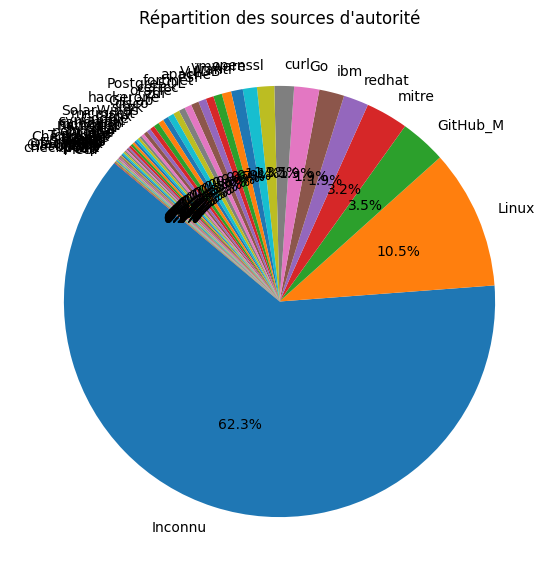

In [105]:
plt.figure(figsize=(7, 7))
df["Organisation d'autorité"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Répartition des sources d'autorité")
plt.ylabel('')
plt.show()

### Top 10 des Vendeurs les plus affectés

Pour voir quel éditeur demande le plus de travail de mise à jour cette semaine.

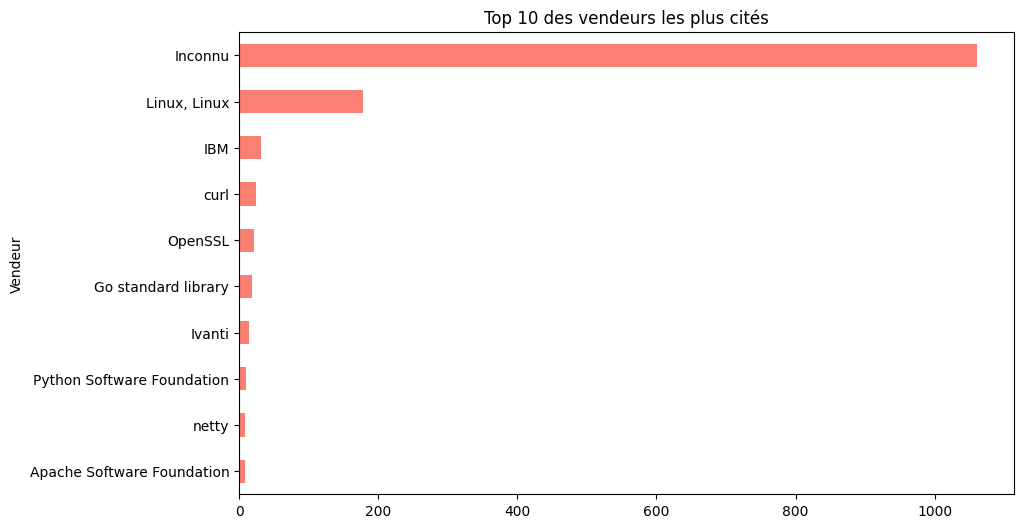

In [106]:
plt.figure(figsize=(10, 6))
df['Vendeur'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.gca().invert_yaxis() # Pour avoir le plus gros en haut
plt.title('Top 10 des vendeurs les plus cités')
plt.show()

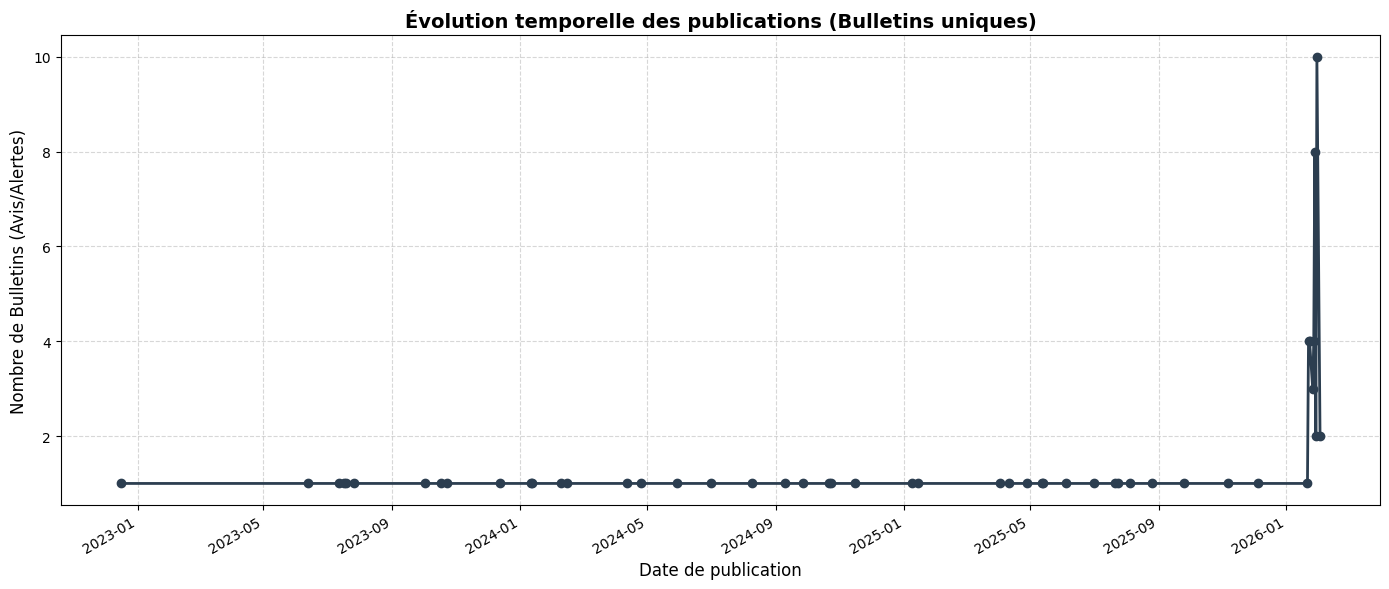

--- Jours de plus forte activité ---
                     Date  Nombre de Bulletins
2026-01-30 00:00:00+00:00                   10
2026-01-28 00:00:00+00:00                    8
2026-01-22 00:00:00+00:00                    4
2026-01-23 00:00:00+00:00                    4
2026-01-27 00:00:00+00:00                    4
2026-01-26 00:00:00+00:00                    3
2026-01-29 00:00:00+00:00                    2
2026-02-02 00:00:00+00:00                    2
2023-10-23 00:00:00+00:00                    1
2023-06-13 00:00:00+00:00                    1


In [110]:
# 1. Nettoyage des doublons pour l'analyse temporelle
# On garde un seul exemplaire de chaque bulletin (identifié par son titre unique)
df_temporel = df.drop_duplicates(subset=['Bulletin_Titre']).copy()
df_temporel['Bulletin_Date'] = pd.to_datetime(df_temporel['Bulletin_Date'])

# 2. Agrégation des données par date
# On compte le nombre de bulletins par jour
evol_bulletins = df_temporel.groupby('Bulletin_Date').size().sort_index()

# 3. Création du graphique
plt.figure(figsize=(14, 6))
evol_bulletins.plot(kind='line', marker='o', color='#2c3e50', linewidth=2, markersize=6)

# Personnalisation visuelle
plt.title("Évolution temporelle des publications (Bulletins uniques)", fontsize=14, fontweight='bold')
plt.xlabel("Date de publication", fontsize=12)
plt.ylabel("Nombre de Bulletins (Avis/Alertes)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Tableau de données récapitulatif (Axe de comparaison)
# Ce tableau montre les jours de forte activité
tableau_activite = evol_bulletins.reset_index()
tableau_activite.columns = ['Date', 'Nombre de Bulletins']
print("--- Jours de plus forte activité ---")
print(tableau_activite.sort_values(by='Nombre de Bulletins', ascending=False).head(10).to_string(index=False))

In [ ]:
# 1. Nettoyage et conversion
df_temporel = df.drop_duplicates(subset=['Bulletin_Titre']).copy()
df_temporel['Bulletin_Date'] = pd.to_datetime(df_temporel['Bulletin_Date'])

# 2. Agrégation des données par ANNÉE
# On extrait l'année et on compte le nombre de bulletins
evol_annuelle = df_temporel.groupby(df_temporel['Bulletin_Date'].dt.year).size().sort_index()

# 3. Création du graphique (Barres plus adaptées pour des années)
plt.figure(figsize=(10, 6))
evol_annuelle.plot(kind='bar', color='#34495e', edgecolor='black', alpha=0.8)

# Personnalisation visuelle
plt.title("Volume annuel des publications (Bulletins uniques)", fontsize=14, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre de Bulletins (Avis/Alertes)", fontsize=12)
plt.xticks(rotation=0) # Années à l'horizontale
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Tableau de données récapitulatif
tableau_annuel = evol_annuelle.reset_index()
tableau_annuel.columns = ['Année', 'Nombre de Bulletins']
print("--- Récapitulatif par année ---")
print(tableau_annuel.to_string(index=False))

In [107]:
import os

os.makedirs('../exports', exist_ok=True)
os.system('jupyter nbconvert analyse_data.ipynb --to html --no-input --output-dir="../exports"')

[NbConvertApp] Converting notebook analyse_data.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 670587 bytes to ../exports/analyse_data.html


0